## Port accessibility - terminal congestion and tidal downtime
In this notebook, we set up a basic simulation in which two vessels are bound for the same terminal in a port. The terminal consists of a quay and a jetty. However, the jetty is not suitable for the length of the vessels, so they have to request the quay. At this quay, the vessels berth, unload cargo, and deberth, after they sail back to sea. The quay has insufficient length to facilitate both vessels alongside each other. Furthermore, the vessels are tide-bound. We jointly examine terminal congestion and tidal windows.

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
from pyproj import Geod
from shapely.geometry import Point, LineString

# package(s) related to the hydrodynamics and tidal windows
import xarray as xr

# load OpenTNSim modules
from opentnsim.core import Identifiable, Movable, VesselProperties
from opentnsim.environment.mixins.hydrodynamics import HydrodynamicData
from opentnsim.graph.mixins import HasMultiDiGraph
from opentnsim.graph.calculations import calculate_distance_along_path
from opentnsim.graph.visualizations import plot_graph
from opentnsim.port.mixins.tidal_accessibility import HasDraughtRestrictions
from opentnsim.port.mixins.anchorage_area import IsAnchorage, PassesAnchorage
from opentnsim.port.mixins.port import IsPort, HasPortAccess
from opentnsim.port.mixins.berth import IsJetty, IsQuay
from opentnsim.port.mixins.terminal import IsTerminal, HasTerminal
from opentnsim.port.rule_constructor import vessel_characteristics, vessel_direction, vessel_type
from opentnsim.port.tidal_window_constructor import vessel_specifications, \
                                                    vertical_tidal_window_specifications, \
                                                    vertical_tidal_window_input, \
                                                    horizontal_tidal_window_specifications, \
                                                    horizontal_tidal_window_method, \
                                                    horizontal_tidal_window_input, \
                                                    tidal_period, \
                                                    accessibility, \
                                                    NetworkProperties

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim

# package(s) needed for inspecting the output
import pandas as pd
import numpy as np
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.visualizations import generate_vessel_gantt_chart

# package(s) for plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.4


#### Define input
vessel

In [2]:
vessel_length = 300
vessel_beam = 40
vessel_draught = 14.2
vessel_speed = 4.5 #m/s
vessel_loading_time = 6 #hours

infrastructure

In [3]:
waterway_length = 30000 #meters
waterway_depth = 15 #meters (NGD: nautical guaranteed depth = MBL: maintained bed level)

harbour_basin_depth = 16.5
anchorage_area_depth = 17

tide

In [4]:
tidal_period = 12.5 #hours
tidal_range_sea = 2.0 #meters
tidal_propagation_speed = np.sqrt(9.81*waterway_depth) #meters per second (np.sqrt(grav_acc*waterway_depth)), grav_acc=9.81
tidal_amplication = 0.8 #amplification factor

tidal restrictions

In [5]:
#percentage of the draught as UKC (10% of draught is common)
ukc_percentage_sea = 10.0 #% of draught 
ukc_percentage_canal = 10.0 #% of draught

#static value as UKC (0.5 m is common, but not in combination with ukc_percentage)
ukc_static_sea = 0.0 #meters
ukc_static_canal = 0.0 #meters

#freshwater allowance as percentage of draught as additional UKC: saltwater at sea (no sinkage), fresher water in port (5% extra sinkage common)
fwa_sea = 0.0 #% of draught
fwa_canal = 0.0 #% of draught

#### 0. Create environment

In [6]:
# set simulation time
simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
simulation_stop = datetime.datetime(2024, 1, 8, 0, 0, 0)

# create time series aligned with simulation time
timestep = pd.Timedelta(minutes=5)
time_series = pd.date_range(simulation_start,simulation_stop,freq=timestep)

env = simpy.Environment(initial_time=simulation_start.timestamp())
env.simulation_start = simulation_start
env.simulation_stop = simulation_stop
env.epoch = simulation_start

#### 1. Create graph
Next we create a network (a graph) along which the vessel can move. For this case we create a single edge of 100 km exactly.

In [7]:
# initialize geodetic calculator with WGS84 ellipsoid
geod = Geod(ellps="WGS84")

In [8]:
# starting point (longitude, latitude)
coordinates_sea = (0,0)

# compute the other point 100 km East from Point 0
coordinates_port = geod.fwd(coordinates_sea[0], coordinates_sea[1], 90 ,waterway_length) # East from Point 0

# define nodes with their geographic coordinates
coordinates_waterway = {"Sea": (coordinates_sea[0], coordinates_sea[1]),
                        "Port basin": (coordinates_port[0], coordinates_port[1]),}

In [9]:
# create list of edges
edges = [("Sea", "Port basin"), ("Port basin", "Sea")] # bi-directional edge

In [10]:
# create a directed graph
graph = nx.DiGraph()

# add nodes
for name, coordinate in coordinates_waterway.items():
    graph.add_node(name, geometry=Point(coordinate[0], coordinate[1]))

# add edges
for edge in edges:
    graph.add_edge(edge[0], edge[1], geometry=LineString([Point(coordinates_sea),Point(coordinates_port[:-1])]), weight=1, length_m=waterway_length)

In [11]:
plot_graph(graph)

In [12]:
# add graph to environment
env.graph = graph

#### 1+ Adding environmental data

In [13]:
# create empty hydrodynamic dataset
hydrodynamic_data = xr.Dataset()

In [14]:
tidal_phase_shift = pd.Timedelta(seconds=waterway_length/tidal_propagation_speed)

tidal_water_level_sea = (tidal_range_sea/2)*np.sin(2*np.pi*((time_series-simulation_start)/(12.5*pd.Timedelta(hours=1))))
tidal_water_level_port = tidal_amplication*(tidal_range_sea/2)*np.sin(2*np.pi*((time_series-simulation_start-tidal_phase_shift)/(12.5*pd.Timedelta(hours=1))))

In [15]:
water_level_data = xr.DataArray(data=[tidal_water_level_sea,tidal_water_level_port],coords={'STATION':graph.nodes,'TIME':time_series})
MBLs = waterway_depth*np.ones(len(time_series))
MBL_data = xr.DataArray(data=[MBLs,MBLs],coords={'STATION':graph.nodes,'TIME':time_series})
hydrodynamic_data['Water level'] = water_level_data
hydrodynamic_data['Nautical depth'] = MBL_data

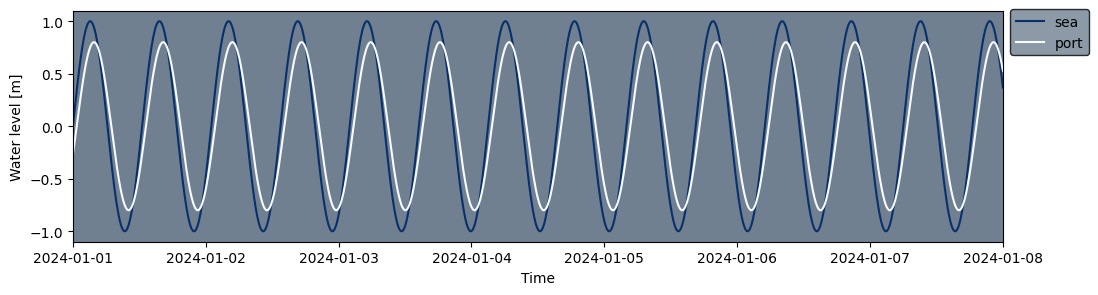

In [16]:
fig,ax = plt.subplots(figsize=[12,3])
ax.set_facecolor('slategrey')
cmap = plt.get_cmap('Blues_r')
ax.plot(time_series,tidal_water_level_sea,color=cmap(0),label='sea')
ax.plot(time_series,tidal_water_level_port,color=cmap(cmap.N),label='port')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel('Time')
ax.set_ylabel('Water level [m]')
ax.set_xlim(time_series[0],time_series[-1])
ax.legend(loc='upper right',frameon=True,bbox_to_anchor=[1.1,1.0375],facecolor='slategray',edgecolor='k');

In [17]:
data = HydrodynamicData(env=env, hydrodynamic_data = hydrodynamic_data)

In [18]:
ukc_p = [ukc_percentage_sea/100,ukc_percentage_canal/100] #percentage of the UKC (10% of draught is common)
ukc_s = [ukc_static_sea,ukc_static_canal] #static value of the UKC
fwa = [fwa_sea/100,fwa_canal/100] #freshwater allowance as percentage of UKC: saltwater at sea (no sinkage), fresher water in port (5% extra sinkage)

network_properties = NetworkProperties()
for index,node in enumerate(graph.nodes):
    graph.nodes[node]['Vertical tidal restriction'] = {}
    vertical_tidal_window_inputs = []

    vessel_specification = vessel_specifications({vessel_characteristics.min_ge_Draught: 0.0},'x',vessel_direction.inbound)
    window_specification = vertical_tidal_window_specifications(ukc_s = ukc_s[index],
                                                                ukc_p = ukc_p[index],
                                                                fwa = fwa[index],)
    
    vertical_tidal_window_inputs.append(vertical_tidal_window_input(vessel_specifications = vessel_specification,
                                                                    window_specifications = window_specification))

    network_properties.append_vertical_tidal_restriction_to_network(env.graph,node,vertical_tidal_window_inputs)

#### 1+ Adding infrastructure

In [19]:
port = IsPort(env=env, name = "Port", port_entry_nodes=['Sea'])

In [20]:
anchorage = IsAnchorage(env=env, capacity=20, name = 'Anchorage', node = 'Sea', depth = anchorage_area_depth, geometry=env.graph.nodes['Sea']['geometry'], port = port)

In [21]:
quay = IsQuay(env=env, length=500, depth=harbour_basin_depth, name='Quay',node='Port basin')
jetty = IsJetty(env=env, length=250, depth=harbour_basin_depth, name='Jetty',node='Port basin')
berths = [quay,jetty]

terminal = IsTerminal(env=env, name = 'Terminal', berths=berths, port = port)

#### 2. Create agents

In [22]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (HasPortAccess,
     HasTerminal,
     PassesAnchorage,
     HasDraughtRestrictions,
     HasMultiDiGraph,
     Identifiable, # allows to give the object a name and a random ID,
     Movable,      # allows the object to move, with a fixed speed, while logging this activity
     VesselProperties,
    ), 
    {}
)

In [23]:
def mission(env, vessel, arrival_time = simulation_start):
    """
    Method that defines the mission of the vessel. 
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    if arrival_time < simulation_start:
        raise ValueError("The vessel's arrival time at the port should be later that the simulation start time")
    else:
        delay = (arrival_time - simulation_start).total_seconds()
        yield vessel.env.timeout(delay)
    yield from vessel.move()

In [24]:
def create_vessel(name, route, next_destination, 
                  vessel_speed = 4.5, berthing_time = 15, loading_time = 6, deberthing_time = 5, 
                  vessel_length = vessel_length, vessel_beam = vessel_beam, vessel_draught = vessel_draught):
    data_vessel = {"env": env,                                        # needed for simpy simulation
                   "name": name,                                      # required by Identifiable
                   "geometry": env.graph.nodes[route[0]]['geometry'], # required by Locatable
                   "route": route,                                    # required by Routeable
                   "v": vessel_speed,                                 # required by Movable, 1 m/s to check if the distance is covered in the expected time
                   "bound": 'inbound',
                   "terminal": terminal,
                   "berthing_time":berthing_time, #minutes
                   "loading_time": loading_time, #hours
                   "deberthing_time":deberthing_time, #minutes
                   "next_destination":next_destination,
                   "type":"tanker",
                   "L":vessel_length,
                   "B":vessel_beam,
                   "T":vessel_draught,
                   }
    vessel = Vessel(**data_vessel)
    return vessel

In [25]:
# create vessel from a dict 
route = nx.dijkstra_path(env.graph, "Sea", "Port basin")
vessel_1 = create_vessel("vessel_1", route, "Sea")
vessel_2 = create_vessel("vessel_2", route, "Sea")

# start the simulation
vessel_1.mission = env.process(mission(env, vessel_1))
vessel_2.mission = env.process(mission(env, vessel_2, arrival_time = simulation_start + pd.Timedelta(hours=3)))

#### 3. Run simulation

In [26]:
env.run()

#### 4. Inspect output

##### Logbook
We can now inspect  the simulation output by inspecting the _vessel.logbook_. Note that the _Log_ mix-in was included when we added _Movable_. The _vessel.logbook_ keeps track of the moving activities of the vessel. For each discrete event OpenTNSim logs an event message, the start/stop time and the location. The _vessel.logbook_ is of type dict. For convenient inspection it can be loaded into a Pandas dataframe. 

In [27]:
# load the logbook data into a dataframe
for vessel in env.vessels:
    df = pd.DataFrame.from_dict(vessel.logbook)
    
    print("'{}' logbook data:".format(vessel.name))  
    print('')
    
    display(df)
    
    if not df.empty:
        trip_distance = calculate_distance_along_path(graph, vessel.route)
        trip_duration = datetime.timedelta.total_seconds(vessel.logbook[-1]['Timestamp'] - vessel.logbook[0]['Timestamp'])
        print("'{}' travelled a distance of {:.1f} meters".format(vessel.name, trip_distance))
        print("'{}' took {:.1f} seconds to arrive at its destination".format(vessel.name, trip_duration)) 
        print("'{}' travelled at an average speed of {:.1f} meters per second".format(vessel.name, trip_distance/trip_duration))
    else:
        print("The port was not accessible for vessel")
    print('')
    print('')

'vessel_1' logbook data:



,Message,Timestamp,Value,Geometry
0,Waiting for Tide start,2024-01-01 00:00:00.000000,0,POINT (0 0)
1,Waiting for Tide stop,2024-01-01 01:25:00.000000,0,POINT (0 0)
2,Sailing from node Sea to node Port basin start,2024-01-01 01:25:00.000000,0,POINT (0 0)
3,Sailing from node Sea to node Port basin stop,2024-01-01 03:16:06.666667,30000,POINT (0.2694945852358564 0)
4,Berthing start,2024-01-01 03:16:06.666667,30000,POINT (0.2694945852358564 0)
5,Berthing stop,2024-01-01 03:31:06.666667,30000,POINT (0.2694945852358564 0)
6,Loading start,2024-01-01 03:31:06.666667,30000,POINT (0.2694945852358564 0)
7,Loading stop,2024-01-01 09:31:06.666667,30000,POINT (0.2694945852358564 0)
8,Waiting for Tide start,2024-01-01 09:31:06.666667,30000,POINT (0.2694945852358564 0)
9,Waiting for Tide stop,2024-01-01 14:50:00.000000,30000,POINT (0.2694945852358564 0)


'vessel_1' travelled a distance of 30000.0 meters
'vessel_1' took 60366.7 seconds to arrive at its destination
'vessel_1' travelled at an average speed of 0.5 meters per second


'vessel_2' logbook data:



,Message,Timestamp,Value,Geometry
0,Waiting for Terminal start,2024-01-01 03:00:00.000000,0,POINT (0 0)
1,Waiting for Terminal stop,2024-01-01 03:20:00.000000,0,POINT (0 0)
2,Waiting for Tide and Terminal start,2024-01-01 03:20:00.000000,0,POINT (0 0)
3,Waiting for Tide and Terminal stop,2024-01-01 13:03:53.333333,0,POINT (0 0)
4,Waiting for Tide start,2024-01-01 13:03:53.333333,0,POINT (0 0)
5,Waiting for Tide stop,2024-01-01 13:54:59.999999,0,POINT (0 0)
6,Sailing from node Sea to node Port basin start,2024-01-01 13:54:59.999999,0,POINT (0 0)
7,Sailing from node Sea to node Port basin stop,2024-01-01 15:46:06.666666,30000,POINT (0.2694945852358564 0)
8,Berthing start,2024-01-01 15:46:06.666666,30000,POINT (0.2694945852358564 0)
9,Berthing stop,2024-01-01 16:01:06.666666,30000,POINT (0.2694945852358564 0)


'vessel_2' travelled a distance of 30000.0 meters
'vessel_2' took 94566.7 seconds to arrive at its destination
'vessel_2' travelled at an average speed of 0.3 meters per second




##### Vessel processes
And the Gantt chart

In [28]:
df_eventtable = logbook2eventtable([vessel_1, vessel_2])
generate_vessel_gantt_chart(df_eventtable)

##### Tidal windows

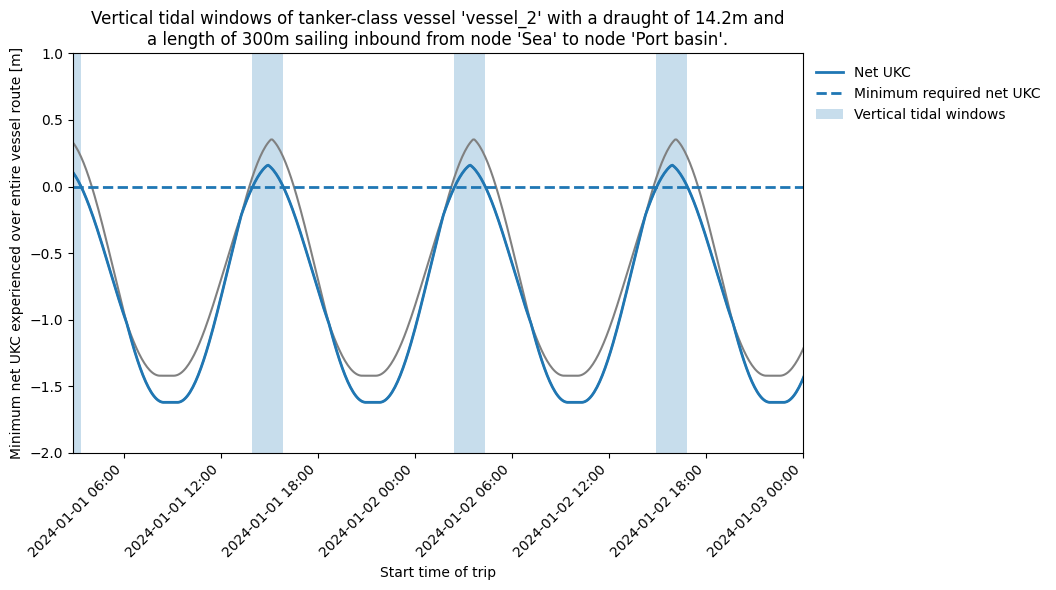

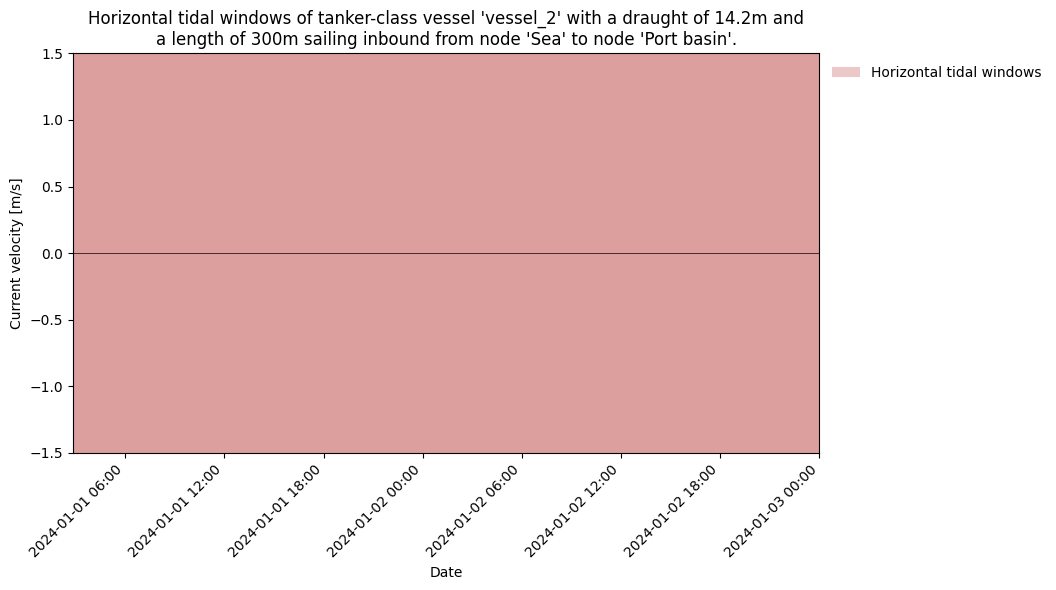

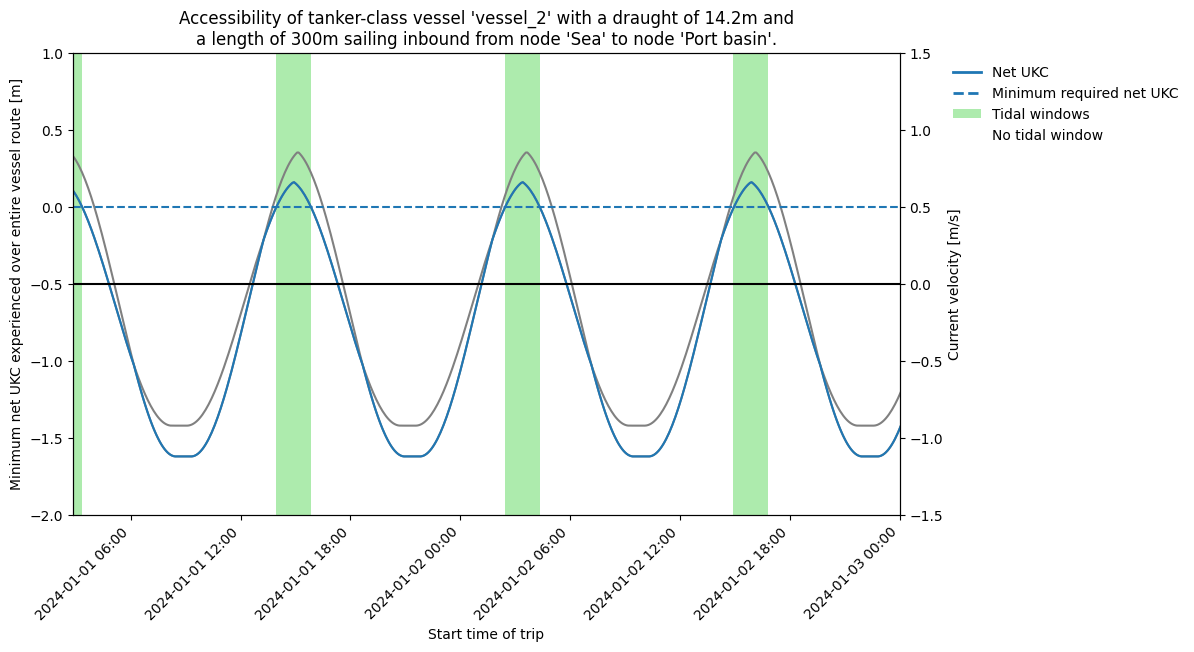

In [29]:
trip_index = 0
fig = vessel_2.plot_tidal_windows(trip_index=trip_index, plot_all = True)
fig

##### Vessel trajectories
We can plot the vessel trajectories. The first vessel can only deberth when there is a tidal window, while the second vessel can only start approaching the terminal when its tidal window starts. This causes a small gap in the departure and arrival at the terminal between the vessels.

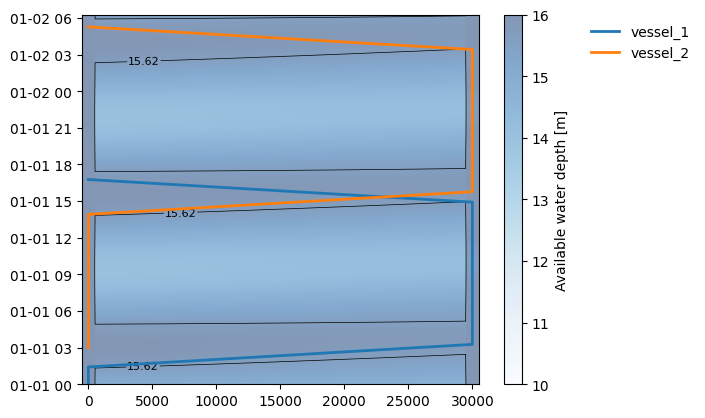

In [30]:
fig = port.plot_vessels('Sea','Port basin',levels=[vessel_draught*1.1],zmin=10,zmax=16)
fig

##### Berth output
We can plot the occupancy of berths over time. The vessels having a length of 300 m are correctly scheduled one after the other at the quay

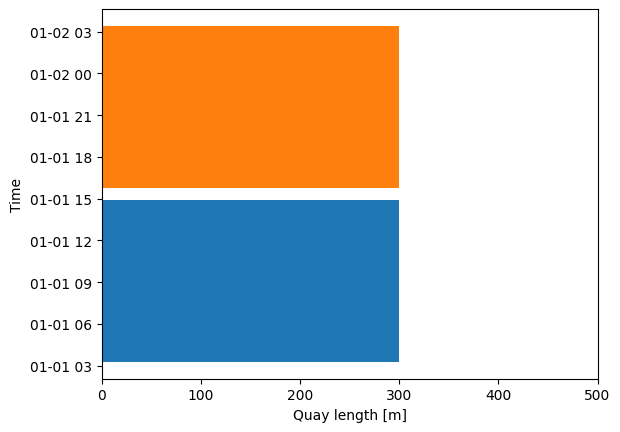

In [31]:
fig = quay.plot_berth_planning()
fig

The jetty indeed remains empty

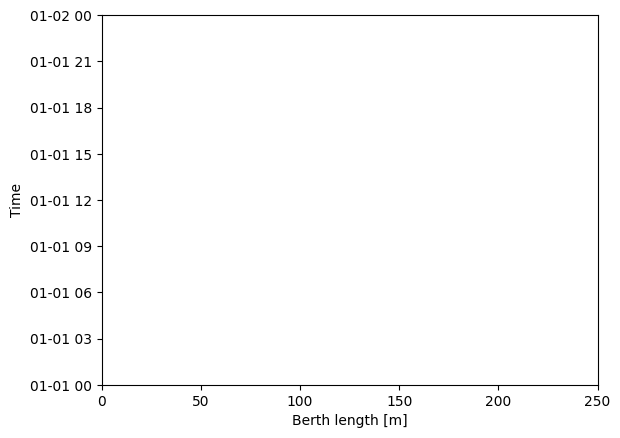

In [32]:
fig = jetty.plot_berth_planning()
fig

##### Berth performance
We can analyse the berth performance of the jetty. The berth performance is acceptable with a berth occupancy of 50.96% and a waiting time rate of 0.53

In [33]:
berth_performance = quay.get_berth_performance(time_stop = pd.Timestamp('2024-01-03'))
berth_performance

Total vessels handled                                                              2
Average vessel length                                                          300.0
Shortest service time                                         0 days 11:38:38.333333
Vessel_id shortest service time                                                    0
Average service time                                       0 days 11:38:38.333333500
Longest service time                                          0 days 11:38:38.333334
Vessel_id longest service time                                                     1
Total service time                                            0 days 23:17:16.666667
Berth occupancy (%)                                                        50.964539
Average waiting time                                       0 days 06:09:59.999999500
Total waiting time                                            0 days 12:19:59.999999
Waiting time rate                                                